In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

['NanumBarunGothic', 'NanumGothic', 'NanumGothicCoding', 'NanumMyeongjo', 'NanumSquare', 'NanumSquareRound']


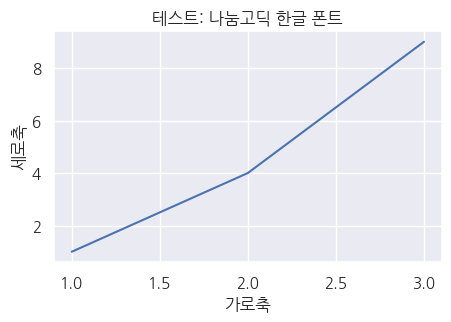

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 설치된 한글 폰트 확인 (NanumGothic, NanumBarunGothic 등 있을 수 있음)
print(sorted({f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name}))

# 대표 폰트로 NanumGothic (없으면 NanumBarunGothic 사용)
plt.rc('font', family='NanumGothic')     # 만약 없으면 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set(font='NanumGothic', rc={'axes.unicode_minus':False})

# 테스트
plt.figure(figsize=(5,3))
plt.title('테스트: 나눔고딕 한글 폰트')
plt.plot([1, 2, 3], [1, 4, 9])
plt.xlabel('가로축')
plt.ylabel('세로축')
plt.show()


<ipython-input-12-fc2900b644ae>:73: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(pred_train), alpha=0.4, label='Train')
<ipython-input-12-fc2900b644ae>:74: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test),  np.log1p(pred_test),  alpha=0.7, label='Test')


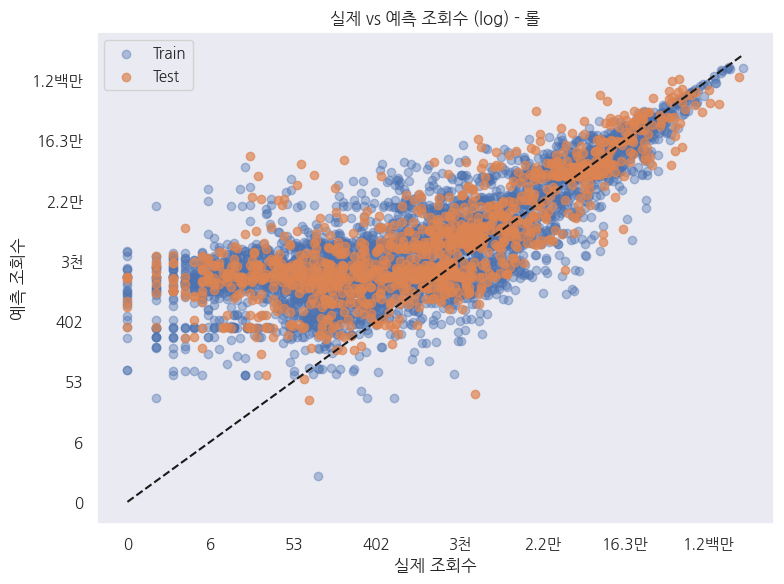

<ipython-input-12-fc2900b644ae>:73: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(pred_train), alpha=0.4, label='Train')
<ipython-input-12-fc2900b644ae>:74: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test),  np.log1p(pred_test),  alpha=0.7, label='Test')


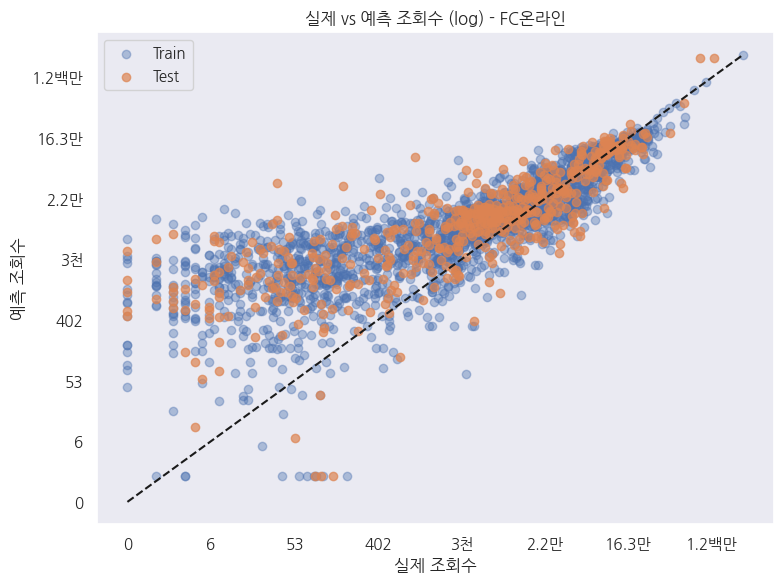

<ipython-input-12-fc2900b644ae>:73: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(pred_train), alpha=0.4, label='Train')
<ipython-input-12-fc2900b644ae>:74: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test),  np.log1p(pred_test),  alpha=0.7, label='Test')


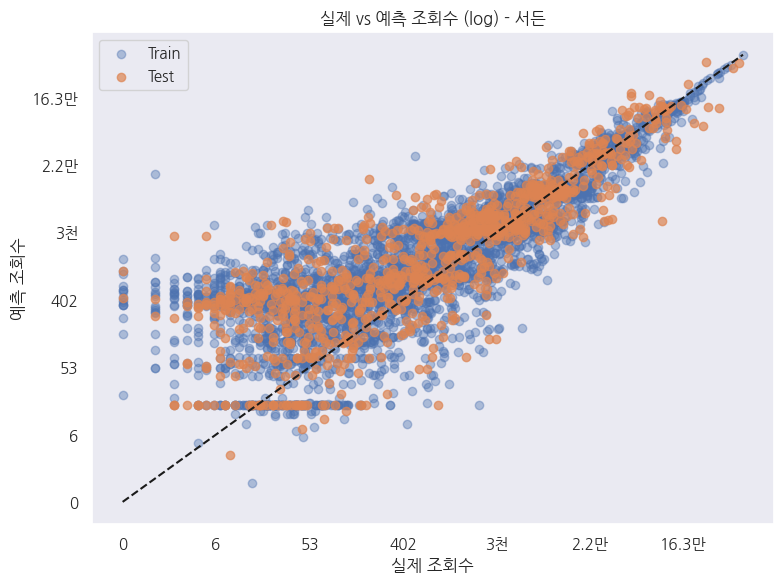

<ipython-input-12-fc2900b644ae>:73: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(pred_train), alpha=0.4, label='Train')
<ipython-input-12-fc2900b644ae>:74: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test),  np.log1p(pred_test),  alpha=0.7, label='Test')


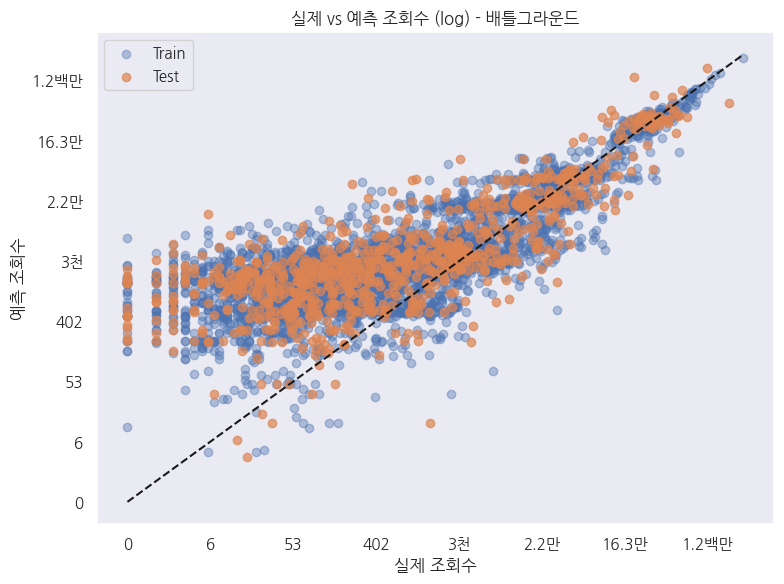

<ipython-input-12-fc2900b644ae>:73: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(pred_train), alpha=0.4, label='Train')
<ipython-input-12-fc2900b644ae>:74: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test),  np.log1p(pred_test),  alpha=0.7, label='Test')


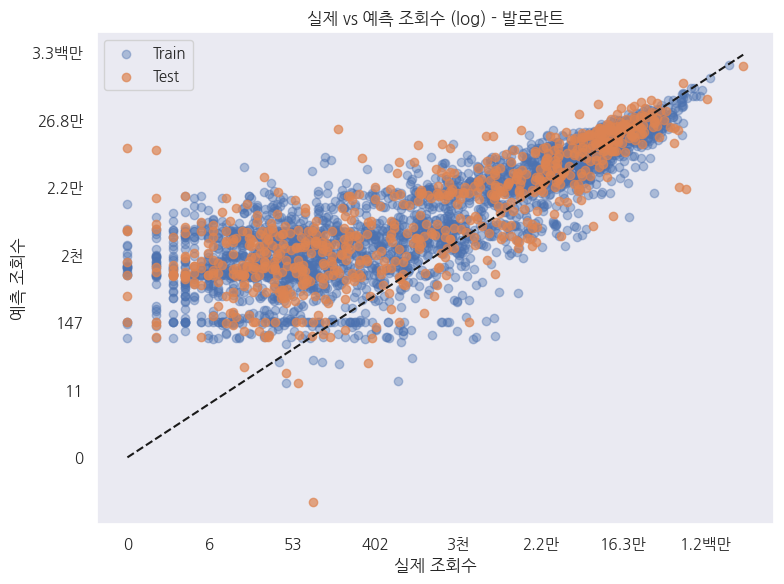


=== 게임별 성능 ===
      게임명          RMSE        R2
0       롤  76444.972732  0.659868
1   FC온라인  70537.531116  0.165795
2      서든  16362.471696  0.747810
3  배틀그라운드  72686.145695  0.568292
4    발로란트  70881.813069  0.725596

=== 전체 데이터 모델링 ===
전체 데이터 RMSE: 56589, R²: 0.654


<ipython-input-12-fc2900b644ae>:73: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(pred_train), alpha=0.4, label='Train')
<ipython-input-12-fc2900b644ae>:74: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test),  np.log1p(pred_test),  alpha=0.7, label='Test')


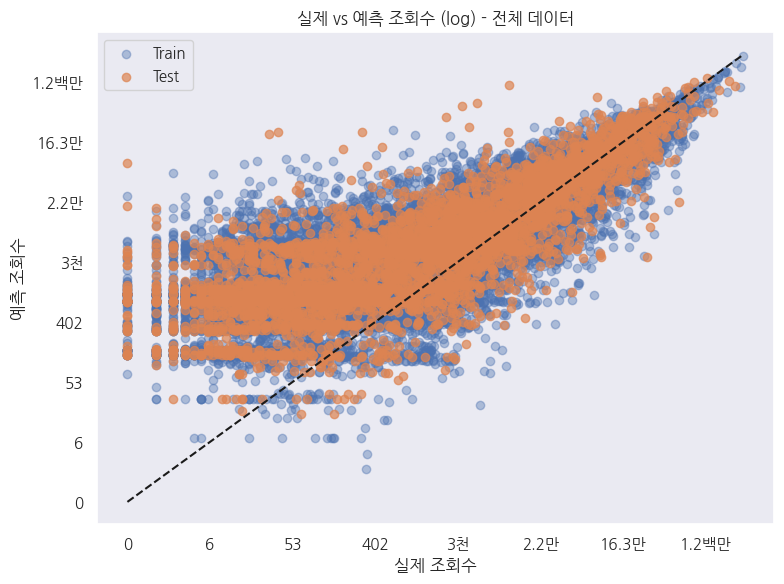

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.ticker as ticker

# 0) 파일 경로 설정 및 존재 확인
file_path = 'final_data.csv'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"파일을 찾을 수 없습니다: {file_path}")

# 1) 데이터 로드
df = pd.read_csv(file_path, encoding='cp949')

# 2) 시간대 분류 함수
def categorize_hour(hour):
    try:
        h = int(hour)
        if 6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else: return '새벽'
    except:
        return np.nan

df['시간대'] = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)

# 3) 피처 & 타깃 설정
feature_cols = [
    # 영상 데이터
    '영상길이(초)', '채널총조회수', '채널업로드영상수', '자막_topic_score',
    '업로드_경과일', '게시_분기',
    # 썸네일 정보
    '텍스트_개수', '텍스트_신뢰도', '텍스트_비중',
    '얼굴_개수', '얼굴_비중',
    # 감정 분포
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy',
    '감정_sad', '감정_surprise', '감정_neutral',
    # 업로드 빈도
    'upload_interval_score', 'mean_interval_score',
    # 제목 기반 정보
    '제목_평균조회수', '제목_tag_mean_score', '제목_토픽_기반_예상조회수',
    # 범주형 파생
    '요일', '시간대', '주요_감정', '얼굴_감지여부'
]
target_col = '조회수'

categorical_features = ['요일', '시간대', '주요_감정']
numeric_features     = [c for c in feature_cols if c not in categorical_features]

# 4) 로그 스케일 축 포맷터
def format_log_ticks(val, pos):
    true = np.expm1(val)
    if true >= 1e6:
        return f"{true/1e6:.1f}백만"
    elif true >= 1e4:
        return f"{true/1e4:.1f}만"
    elif true >= 1e3:
        return f"{true/1e3:.0f}천"
    else:
        return f"{int(true)}"

# 5) 시각화 함수
def plot_compare(y_train, pred_train, y_test, pred_test, title_tag):
    plt.figure(figsize=(8,6))
    plt.scatter(np.log1p(y_train), np.log1p(pred_train), alpha=0.4, label='Train')
    plt.scatter(np.log1p(y_test),  np.log1p(pred_test),  alpha=0.7, label='Test')
    mn = min(np.log1p(y_train).min(), np.log1p(y_test).min())
    mx = max(np.log1p(y_train).max(), np.log1p(y_test).max())
    plt.plot([mn,mx], [mn,mx], 'k--')
    plt.title(f'실제 vs 예측 조회수 (log) - {title_tag}')
    plt.xlabel('실제 조회수'); plt.ylabel('예측 조회수')
    plt.legend(); plt.grid()
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    plt.tight_layout(); plt.show()

# 6) 전처리 + 모델 파이프라인
preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

model_pipeline = Pipeline([
    ('prep', preprocessor),
    ('xgb', XGBRegressor(
        n_estimators=100, max_depth=4,
        learning_rate=0.1, random_state=42))
])

# 7) 게임별 모델링
results = []
for game in df['게임명'].dropna().unique():
    sub = df[df['게임명'] == game]
    data = sub[feature_cols + [target_col]].dropna()
    if data.shape[0] < 100:
        print(f"▶ {game}: 데이터 {data.shape[0]}건 부족, 스킵")
        continue

    X = data[feature_cols]
    y = data[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model_pipeline.fit(X_train, y_train)
    y_tr = model_pipeline.predict(X_train)
    y_te = model_pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_te))
    r2   = r2_score(y_test, y_te)
    results.append({'게임명': game, 'RMSE': rmse, 'R2': r2})
    plot_compare(y_train, y_tr, y_test, y_te, title_tag=game)

# 8) 게임별 성능 요약
res_games = pd.DataFrame(results)
print("\n=== 게임별 성능 ===")
print(res_games)


# 9) 전체 데이터 모델링
print("\n=== 전체 데이터 모델링 ===")
full_data = df[feature_cols + [target_col]].dropna()
X_full = full_data[feature_cols]
y_full = full_data[target_col]

X_tr_full, X_te_full, y_tr_full, y_te_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)
model_pipeline.fit(X_tr_full, y_tr_full)
y_tr_full_pred = model_pipeline.predict(X_tr_full)
y_te_full_pred = model_pipeline.predict(X_te_full)

rmse_full = np.sqrt(mean_squared_error(y_te_full, y_te_full_pred))
r2_full   = r2_score(y_te_full, y_te_full_pred)
print(f"전체 데이터 RMSE: {rmse_full:.0f}, R²: {r2_full:.3f}")

plot_compare(y_tr_full, y_tr_full_pred, y_te_full, y_te_full_pred, title_tag="전체 데이터")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001795 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3249
[LightGBM] [Info] Number of data points in the train set: 5456, number of used features: 41
[LightGBM] [Info] Start training from score 30472.239003
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-13-25e77f622f05>:81: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(y_pred_train),
<ipython-input-13-25e77f622f05>:83: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test), np.log1p(y_pred_test),


▶ 롤: RMSE=76071, R²=0.663


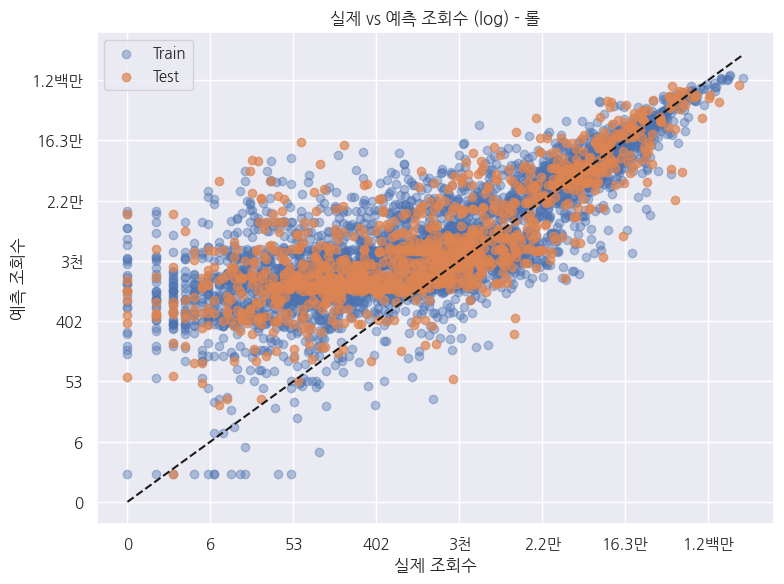

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000688 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3206
[LightGBM] [Info] Number of data points in the train set: 2650, number of used features: 41
[LightGBM] [Info] Start training from score 25608.202264
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-13-25e77f622f05>:81: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(y_pred_train),
<ipython-input-13-25e77f622f05>:83: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test), np.log1p(y_pred_test),


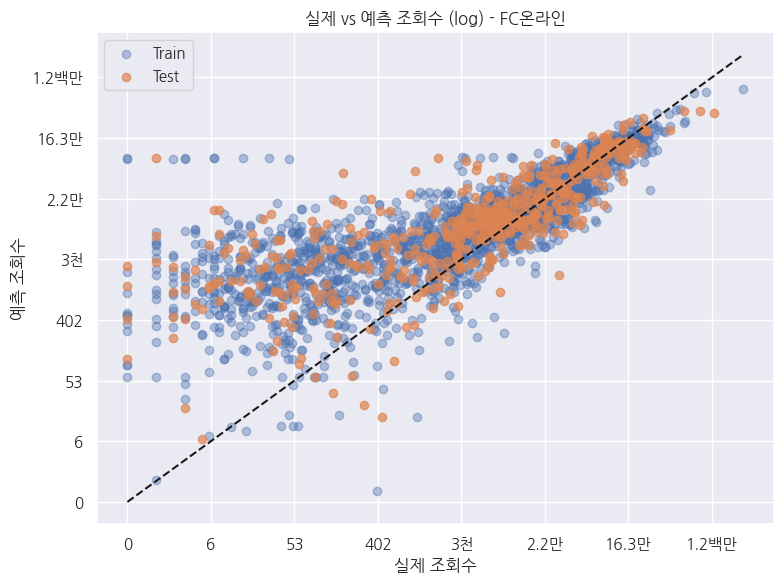

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001132 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3132
[LightGBM] [Info] Number of data points in the train set: 4859, number of used features: 41
[LightGBM] [Info] Start training from score 7480.573369
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-13-25e77f622f05>:81: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(y_pred_train),
<ipython-input-13-25e77f622f05>:83: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test), np.log1p(y_pred_test),


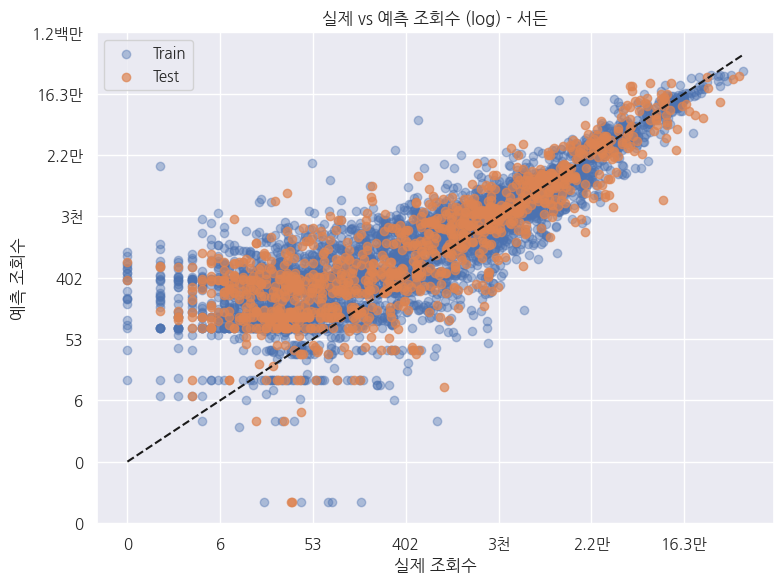

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001014 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2838
[LightGBM] [Info] Number of data points in the train set: 4054, number of used features: 41
[LightGBM] [Info] Start training from score 29511.024174
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-13-25e77f622f05>:81: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(y_pred_train),
<ipython-input-13-25e77f622f05>:83: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test), np.log1p(y_pred_test),


▶ 배틀그라운드: RMSE=63016, R²=0.676


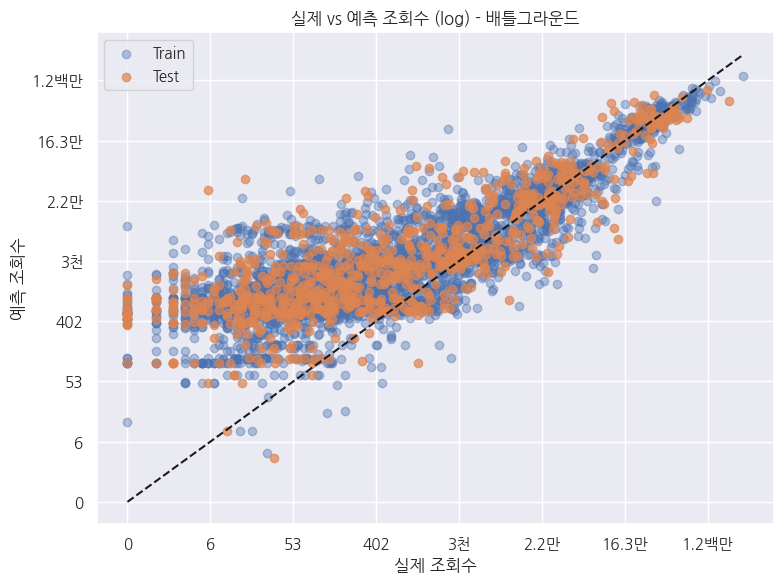

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001418 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3140
[LightGBM] [Info] Number of data points in the train set: 3677, number of used features: 41
[LightGBM] [Info] Start training from score 39743.975252
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-13-25e77f622f05>:81: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(y_pred_train),
<ipython-input-13-25e77f622f05>:83: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test), np.log1p(y_pred_test),


▶ 발로란트: RMSE=94971, R²=0.507


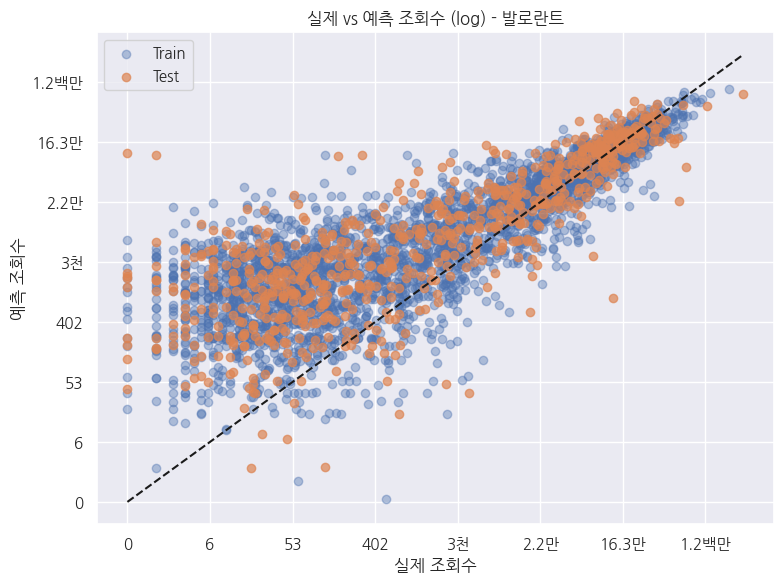


=== 게임별 성능 요약 ===
      게임명          RMSE        R2
0       롤  76070.738287  0.663190
1   FC온라인  47244.295005  0.625777
2      서든  18876.081052  0.664375
3  배틀그라운드  63016.098661  0.675519
4    발로란트  94970.565805  0.507396

=== 전체 데이터 모델링 ===
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005156 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3834
[LightGBM] [Info] Number of data points in the train set: 20698, number of used features: 42
[LightGBM] [Info] Start training from score 26213.912262


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-13-25e77f622f05>:81: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(y_pred_train),
<ipython-input-13-25e77f622f05>:83: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test), np.log1p(y_pred_test),


전체 데이터: RMSE=53022, R²=0.696


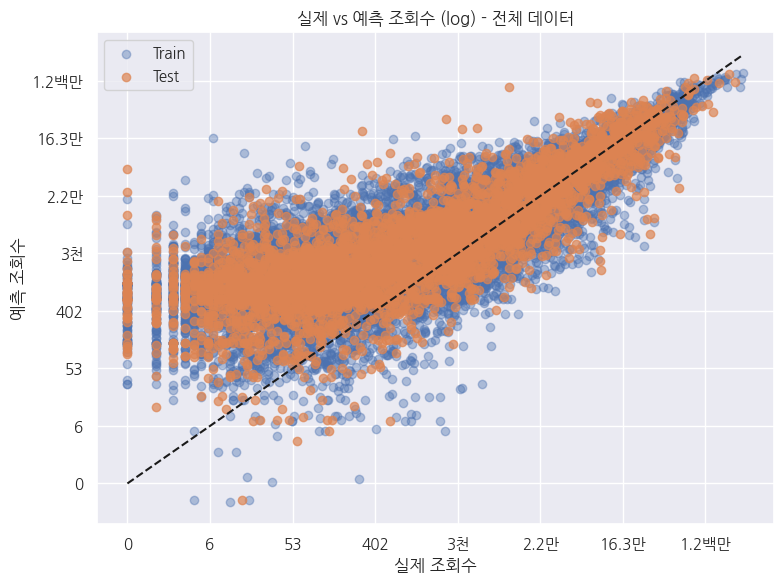

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.ticker as ticker

# 0) 파일 경로 설정 및 확인
file_path = 'final_data.csv'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"파일을 찾을 수 없습니다: {file_path}")

# 1) 데이터 로드
df = pd.read_csv(file_path, encoding='cp949')

# 2) 시간대 분류 함수
def categorize_hour(hour):
    """
    업로드 시각을 받아 '새벽', '오전', '오후', '저녁'으로 분류합니다.
    """
    try:
        h = int(hour)
        if 6 <= h < 12:
            return '오전'
        elif 12 <= h < 18:
            return '오후'
        elif 18 <= h < 24:
            return '저녁'
        else:
            return '새벽'
    except:
        return np.nan

# 파생 변수 추가
df['시간대'] = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)

# 3) 피처 및 타깃 설정
feature_cols = [
    # 영상 메타데이터
    '영상길이(초)', '채널총조회수', '채널업로드영상수', '자막_topic_score',
    '업로드_경과일', '게시_분기',
    # 썸네일 정보
    '텍스트_개수', '텍스트_신뢰도', '텍스트_비중',
    '얼굴_개수', '얼굴_비중',
    # 감정 분포
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy',
    '감정_sad', '감정_surprise', '감정_neutral',
    # 업로드 빈도
    'upload_interval_score', 'mean_interval_score',
    # 제목 기반 예측 정보
    '제목_평균조회수', '제목_tag_mean_score', '제목_토픽_기반_예상조회수',
    # 파생 범주형
    '요일', '시간대', '주요_감정', '얼굴_감지여부'
]
target_col = '조회수'

categorical_features = ['요일', '시간대', '주요_감정']
numeric_features = [c for c in feature_cols if c not in categorical_features]

# 4) 로그 스케일 축 포맷터
def format_log_ticks(val, pos):
    true = np.expm1(val)
    if true >= 1e6:
        return f"{true/1e6:.1f}백만"
    elif true >= 1e4:
        return f"{true/1e4:.1f}만"
    elif true >= 1e3:
        return f"{true/1e3:.0f}천"
    else:
        return f"{int(true)}"

# 5) 실제 vs 예측 시각화 함수
def plot_compare(y_train, y_pred_train, y_test, y_pred_test, title_tag):
    plt.figure(figsize=(8, 6))
    plt.scatter(np.log1p(y_train), np.log1p(y_pred_train),
                alpha=0.4, label='Train')
    plt.scatter(np.log1p(y_test), np.log1p(y_pred_test),
                alpha=0.7, label='Test')
    mn = min(np.log1p(y_train).min(), np.log1p(y_test).min())
    mx = max(np.log1p(y_train).max(), np.log1p(y_test).max())
    plt.plot([mn, mx], [mn, mx], 'k--')
    plt.title(f'실제 vs 예측 조회수 (log) - {title_tag}')
    plt.xlabel('실제 조회수')
    plt.ylabel('예측 조회수')
    plt.legend()
    plt.grid(True)
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    plt.tight_layout()
    plt.show()

# 6) 전처리 + LightGBM 파이프라인
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

lgbm_pipeline = Pipeline([
    ('prep', preprocessor),
    ('lgbm', LGBMRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        random_state=42
    ))
])

# 7) 게임별 모델링 및 평가
results = []
for game in df['게임명'].dropna().unique():
    subset = df[df['게임명'] == game]
    data = subset[feature_cols + [target_col]].dropna()
    if data.shape[0] < 100:
        print(f"▶ {game}: 데이터 {data.shape[0]}건으로 부족, 스킵")
        continue

    X = data[feature_cols]
    y = data[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # 학습
    lgbm_pipeline.fit(X_train, y_train)

    # 예측
    y_train_pred = lgbm_pipeline.predict(X_train)
    y_test_pred = lgbm_pipeline.predict(X_test)

    # 평가 지표
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2 = r2_score(y_test, y_test_pred)
    print(f"▶ {game}: RMSE={rmse:.0f}, R²={r2:.3f}")
    results.append({'게임명': game, 'RMSE': rmse, 'R2': r2})

    # 시각화
    plot_compare(y_train, y_train_pred, y_test, y_test_pred, title_tag=game)

# 8) 게임별 성능 요약 출력
results_df = pd.DataFrame(results)
print("\n=== 게임별 성능 요약 ===")
print(results_df)

# 9) 전체 데이터 모델링
print("\n=== 전체 데이터 모델링 ===")
full_data = df[feature_cols + [target_col]].dropna()
X_full = full_data[feature_cols]
y_full = full_data[target_col]
X_tr_full, X_te_full, y_tr_full, y_te_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

# 전체 데이터 학습
lgbm_pipeline.fit(X_tr_full, y_tr_full)
y_tr_full_pred = lgbm_pipeline.predict(X_tr_full)
y_te_full_pred = lgbm_pipeline.predict(X_te_full)

# 전체 데이터 평가
rmse_full = np.sqrt(mean_squared_error(y_te_full, y_te_full_pred))
r2_full = r2_score(y_te_full, y_te_full_pred)
print(f"전체 데이터: RMSE={rmse_full:.0f}, R²={r2_full:.3f}")

# 전체 데이터 시각화
plot_compare(y_tr_full, y_tr_full_pred, y_te_full, y_te_full_pred, title_tag="전체 데이터")



Fitting 3 folds for each of 50 candidates, totalling 150 fits
=== 최적 하이퍼파라미터 ===
{'hgbr__l2_regularization': np.float64(4.4513143156492045), 'hgbr__learning_rate': np.float64(0.1125612361593632), 'hgbr__max_depth': 3, 'hgbr__max_iter': 745, 'hgbr__min_samples_leaf': 32}
튜닝 후 성능 -> RMSE: 56700, R²: 0.652


<ipython-input-14-753b2c30b362>:104: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test), np.log1p(y_pred), alpha=0.6)
<ipython-input-14-753b2c30b362>:105: RuntimeWarning: invalid value encountered in log1p
  mn, mx = min(np.log1p(y_test).min(), np.log1p(y_pred).min()), max(np.log1p(y_test).max(), np.log1p(y_pred).max())


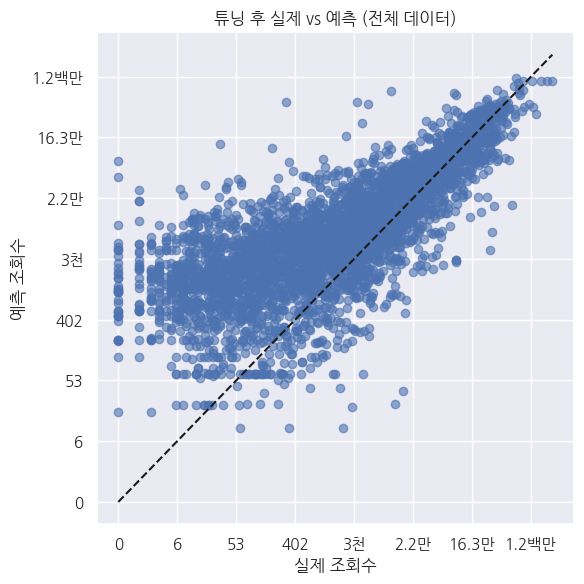

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.ticker as ticker
import scipy.stats as stats

# 1) 파일 경로 설정 및 확인
file_path = 'final_data.csv'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"파일을 찾을 수 없습니다: {file_path}")

# 2) 데이터 로드
df = pd.read_csv(file_path, encoding='cp949')

# 3) 파생 변수 생성
def categorize_hour(hour):
    try:
        h = int(hour)
        if 6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else: return '새벽'
    except:
        return np.nan

df['시간대'] = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)

# 4) 피처 및 타깃 설정
feature_cols = [
    '영상길이(초)', '채널총조회수', '채널업로드영상수', '자막_topic_score',
    '업로드_경과일', '게시_분기',
    '텍스트_개수', '텍스트_신뢰도', '텍스트_비중',
    '얼굴_개수', '얼굴_비중',
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy',
    '감정_sad', '감정_surprise', '감정_neutral',
    'upload_interval_score', 'mean_interval_score',
    '제목_평균조회수', '제목_tag_mean_score', '제목_토픽_기반_예상조회수',
    '요일', '시간대', '주요_감정', '얼굴_감지여부'
]
target_col = '조회수'

# 5) 전처리 및 모델 파이프라인
categorical_features = ['요일', '시간대', '주요_감정']
preprocessor = ColumnTransformer(
    [('ohe', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
    remainder='passthrough'
)
pipeline = Pipeline([
    ('prep', preprocessor),
    ('hgbr', HistGradientBoostingRegressor(random_state=42))
])

# 6) 학습/검증 데이터 분리
data = df[feature_cols + [target_col]].dropna()
X, y = data[feature_cols], data[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7) 하이퍼파라미터 분포 정의
param_dist = {
    'hgbr__max_iter': stats.randint(100, 1000),
    'hgbr__max_depth': stats.randint(3, 10),
    'hgbr__learning_rate': stats.loguniform(0.01, 0.2),
    'hgbr__min_samples_leaf': stats.randint(5, 50),
    'hgbr__l2_regularization': stats.loguniform(1e-4, 10),
}

# 8) RandomizedSearchCV로 튜닝
search = RandomizedSearchCV(
    pipeline, param_distributions=param_dist,
    n_iter=50, cv=3, scoring='neg_root_mean_squared_error',
    verbose=1, random_state=42, n_jobs=-1
)
search.fit(X_train, y_train)

print("=== 최적 하이퍼파라미터 ===")
print(search.best_params_)

# 9) 튜닝된 모델 평가
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"튜닝 후 성능 -> RMSE: {rmse:.0f}, R²: {r2:.3f}")

# 10) 결과 시각화
def format_log(val, pos):
    true = np.expm1(val)
    if true >= 1e6: return f"{true/1e6:.1f}백만"
    elif true >= 1e4: return f"{true/1e4:.1f}만"
    elif true >= 1e3: return f"{true/1e3:.0f}천"
    else: return f"{int(true)}"

plt.figure(figsize=(6,6))
plt.scatter(np.log1p(y_test), np.log1p(y_pred), alpha=0.6)
mn, mx = min(np.log1p(y_test).min(), np.log1p(y_pred).min()), max(np.log1p(y_test).max(), np.log1p(y_pred).max())
plt.plot([mn, mx], [mn, mx], 'k--')
plt.xlabel('실제 조회수'); plt.ylabel('예측 조회수')
plt.title('튜닝 후 실제 vs 예측 (전체 데이터)')
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_log))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_log))
plt.grid(True); plt.tight_layout(); plt.show()


Fitting 3 folds for each of 50 candidates, totalling 150 fits
=== 최적 하이퍼파라미터 ===
{'regressor__hgbr__l2_regularization': np.float64(0.0074593432857265485), 'regressor__hgbr__learning_rate': np.float64(0.17254716573280354), 'regressor__hgbr__max_bins': 206, 'regressor__hgbr__max_depth': 7, 'regressor__hgbr__max_iter': 120, 'regressor__hgbr__max_leaf_nodes': 94, 'regressor__hgbr__min_samples_leaf': 15}
튜닝 후 성능 -> RMSE: 60847, R²: 0.599


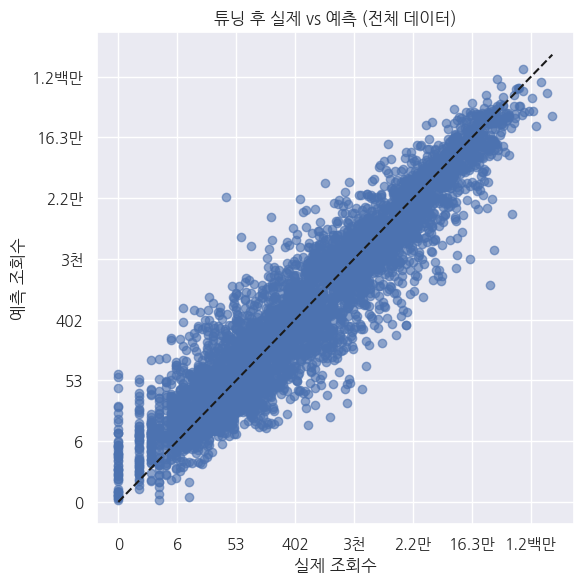

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.ticker as ticker
import scipy.stats as stats

# 1) 파일 경로 설정 및 확인
file_path = 'final_data.csv'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"파일을 찾을 수 없습니다: {file_path}")

# 2) 데이터 로드
df = pd.read_csv(file_path, encoding='cp949')

# 3) 파생 변수 생성: 시간대, 얼굴 감지
def categorize_hour(hour):
    try:
        h = int(hour)
        if 6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else: return '새벽'
    except:
        return np.nan

df['시간대'] = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)

# 4) 추가 피처 엔지니어링: 주말 여부, 업로드 빈도 비율
df['주말여부'] = df['요일'].isin(['토요일', '일요일']).astype(int)
df['interval_ratio'] = df['upload_interval_score'] / (df['mean_interval_score'] + 1e-6)

# 5) 피처 및 타깃 설정
feature_cols = [
    '영상길이(초)', '채널총조회수', '채널업로드영상수', '자막_topic_score',
    '업로드_경과일', '게시_분기',
    '텍스트_개수', '텍스트_신뢰도', '텍스트_비중',
    '얼굴_개수', '얼굴_비중',
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy',
    '감정_sad', '감정_surprise', '감정_neutral',
    'upload_interval_score', 'mean_interval_score', 'interval_ratio',
    '제목_평균조회수', '제목_tag_mean_score', '제목_토픽_기반_예상조회수',
    '요일', '시간대', '주요_감정', '얼굴_감지여부', '주말여부'
]
target_col = '조회수'

# 6) 전처리 + 대상 변환 회귀기
categorical_features = ['요일', '시간대', '주요_감정']
preprocessor = ColumnTransformer(
    [('ohe', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
    remainder='passthrough'
)

base_regressor = HistGradientBoostingRegressor(random_state=42)
model = TransformedTargetRegressor(
    regressor=Pipeline([
        ('prep', preprocessor),
        ('hgbr', base_regressor)
    ]),
    func=np.log1p,
    inverse_func=np.expm1
)

# 7) 학습/검증 데이터 분리
data = df[feature_cols + [target_col]].dropna()
X, y = data[feature_cols], data[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8) 하이퍼파라미터 분포 정의 (HistGradientBoostingRegressor)
param_dist = {
    'regressor__hgbr__max_iter': stats.randint(100, 1000),
    'regressor__hgbr__max_depth': stats.randint(3, 10),
    'regressor__hgbr__learning_rate': stats.loguniform(0.01, 0.2),
    'regressor__hgbr__min_samples_leaf': stats.randint(5, 50),
    'regressor__hgbr__l2_regularization': stats.loguniform(1e-4, 10),
    'regressor__hgbr__max_bins': stats.randint(100, 255),
    'regressor__hgbr__max_leaf_nodes': stats.randint(20, 100),
}

# 9) RandomizedSearchCV로 튜닝
search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=50,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)
search.fit(X_train, y_train)

print("=== 최적 하이퍼파라미터 ===")
print(search.best_params_)

# 10) 튜닝된 모델 평가
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"튜닝 후 성능 -> RMSE: {rmse:.0f}, R²: {r2:.3f}")

# 11) 결과 시각화
def format_log(val, pos):
    true = np.expm1(val)
    if true >= 1e6: return f"{true/1e6:.1f}백만"
    elif true >= 1e4: return f"{true/1e4:.1f}만"
    elif true >= 1e3: return f"{true/1e3:.0f}천"
    else: return f"{int(true)}"

plt.figure(figsize=(6, 6))
plt.scatter(np.log1p(y_test), np.log1p(y_pred), alpha=0.6)
mn, mx = (min(np.log1p(y_test).min(), np.log1p(y_pred).min()),
          max(np.log1p(y_test).max(), np.log1p(y_pred).max()))
plt.plot([mn, mx], [mn, mx], 'k--')
plt.xlabel('실제 조회수'); plt.ylabel('예측 조회수')
plt.title('튜닝 후 실제 vs 예측 (전체 데이터)')
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_log))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_log))
plt.grid(True); plt.tight_layout(); plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002030 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2848
[LightGBM] [Info] Number of data points in the train set: 5456, number of used features: 41
[LightGBM] [Info] Start training from score 30472.239003
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-17-88d3249a62b8>:67: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(y_pred_train),
<ipython-input-17-88d3249a62b8>:69: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test), np.log1p(y_pred_test),


▶ 롤: RMSE=80200, R²=0.626


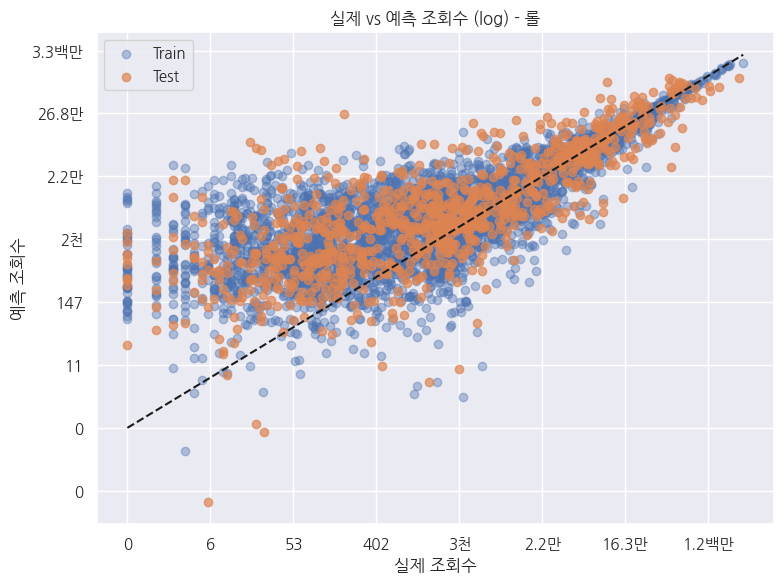

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000751 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2736
[LightGBM] [Info] Number of data points in the train set: 2650, number of used features: 41
[LightGBM] [Info] Start training from score 25608.202264
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-17-88d3249a62b8>:67: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(y_pred_train),
<ipython-input-17-88d3249a62b8>:69: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test), np.log1p(y_pred_test),


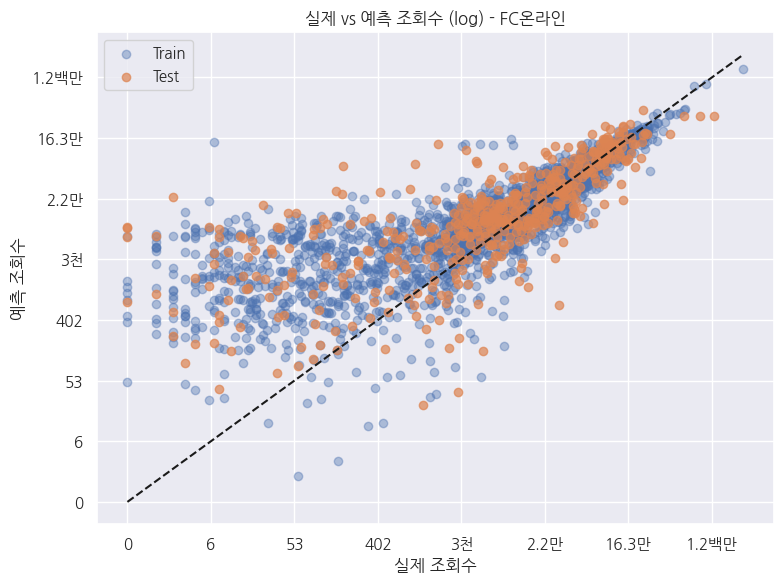

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001706 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2711
[LightGBM] [Info] Number of data points in the train set: 4859, number of used features: 41
[LightGBM] [Info] Start training from score 7480.573369
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-17-88d3249a62b8>:67: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(y_pred_train),
<ipython-input-17-88d3249a62b8>:69: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test), np.log1p(y_pred_test),


▶ 서든: RMSE=19153, R²=0.654


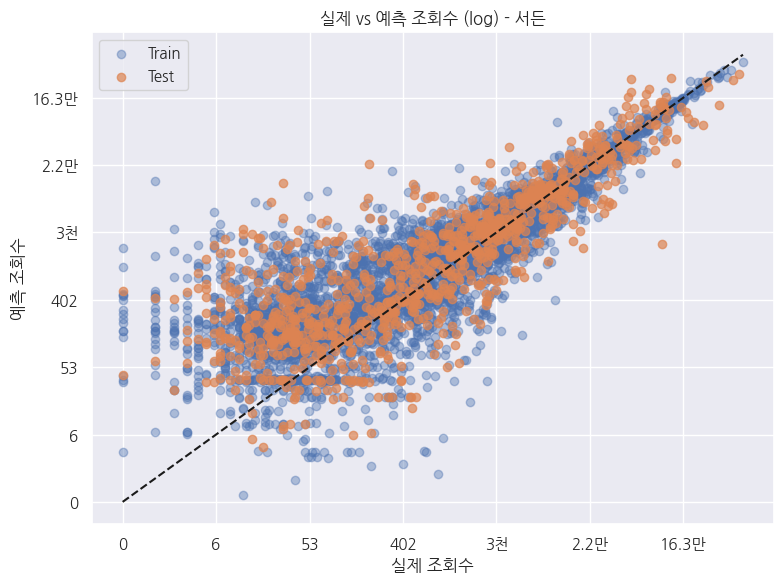

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001479 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2595
[LightGBM] [Info] Number of data points in the train set: 4054, number of used features: 41
[LightGBM] [Info] Start training from score 29511.024174
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-17-88d3249a62b8>:67: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(y_pred_train),
<ipython-input-17-88d3249a62b8>:69: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test), np.log1p(y_pred_test),


▶ 배틀그라운드: RMSE=60768, R²=0.698


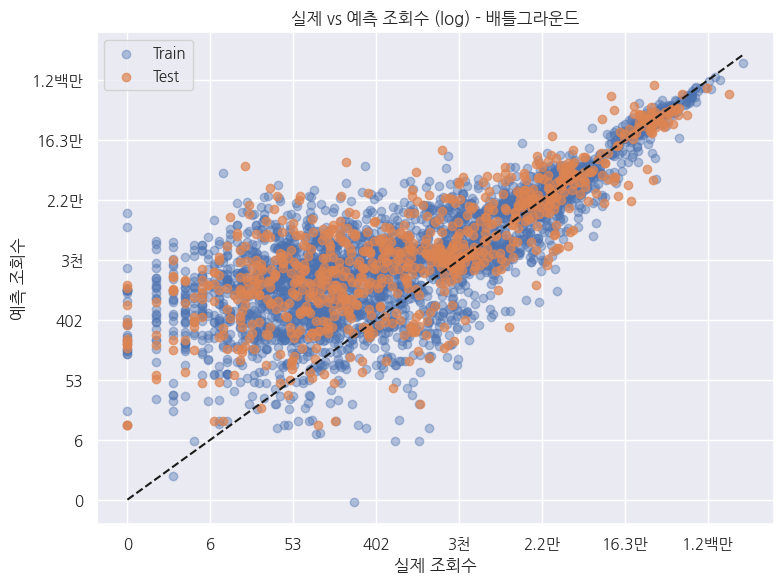

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001527 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2749
[LightGBM] [Info] Number of data points in the train set: 3677, number of used features: 41
[LightGBM] [Info] Start training from score 39743.975252
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-17-88d3249a62b8>:67: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(y_pred_train),
<ipython-input-17-88d3249a62b8>:69: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test), np.log1p(y_pred_test),


▶ 발로란트: RMSE=89581, R²=0.562


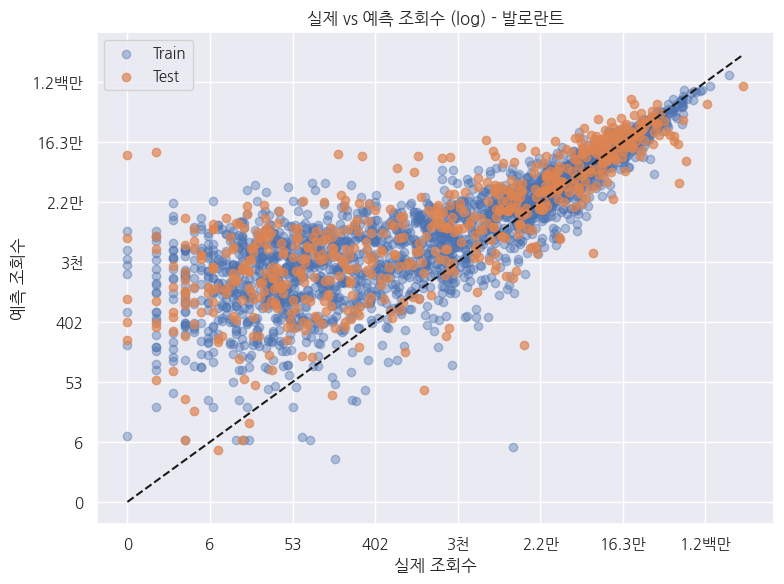


=== 게임별 성능 요약 ===
      게임명          RMSE        R2
0       롤  80199.522429  0.625636
1   FC온라인  51746.164957  0.551060
2      서든  19153.358544  0.654443
3  배틀그라운드  60767.785244  0.698260
4    발로란트  89580.511985  0.561725

=== 전체 데이터 모델링 ===


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026410 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3240
[LightGBM] [Info] Number of data points in the train set: 20698, number of used features: 42
[LightGBM] [Info] Start training from score 26213.912262
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-17-88d3249a62b8>:67: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_train), np.log1p(y_pred_train),
<ipython-input-17-88d3249a62b8>:69: RuntimeWarning: invalid value encountered in log1p
  plt.scatter(np.log1p(y_test), np.log1p(y_pred_test),


전체 데이터: RMSE=55622, R²=0.665


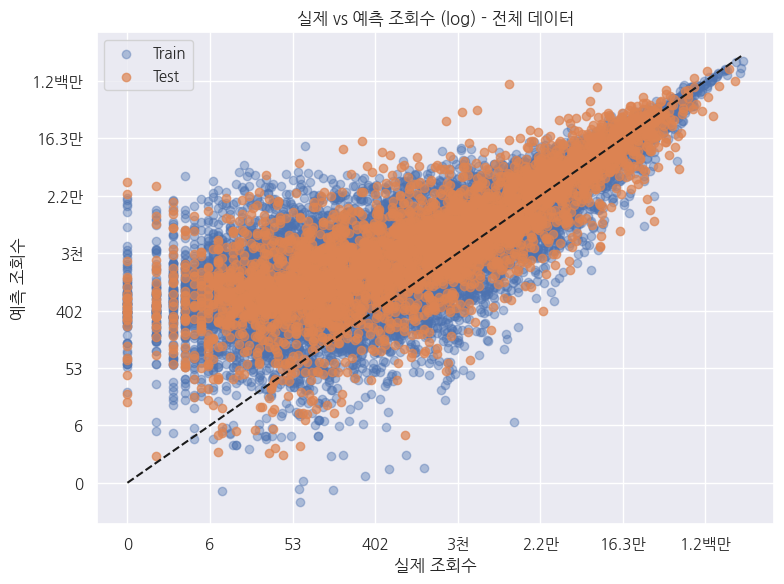

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.ticker as ticker

# 0) 파일 경로 설정 및 확인
file_path = 'final_data.csv'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"파일을 찾을 수 없습니다: {file_path}")

# 1) 데이터 로드
df = pd.read_csv(file_path, encoding='cp949')

# 2) 시간대 분류 함수
def categorize_hour(hour):
    try:
        h = int(hour)
        if 6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else: return '새벽'
    except:
        return np.nan

df['시간대'] = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)

# 3) 피처 및 타깃 설정
feature_cols = [
    '영상길이(초)', '채널총조회수', '채널업로드영상수', '자막_topic_score',
    '업로드_경과일', '게시_분기',
    '텍스트_개수', '텍스트_신뢰도', '텍스트_비중',
    '얼굴_개수', '얼굴_비중',
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy',
    '감정_sad', '감정_surprise', '감정_neutral',
    'upload_interval_score', 'mean_interval_score',
    '제목_평균조회수', '제목_tag_mean_score', '제목_토픽_기반_예상조회수',
    '요일', '시간대', '주요_감정', '얼굴_감지여부'
]
target_col = '조회수'

categorical_features = ['요일', '시간대', '주요_감정']
numeric_features = [c for c in feature_cols if c not in categorical_features]

# 4) 로그 스케일 축 포맷터
def format_log_ticks(val, pos):
    true = np.expm1(val)
    if true >= 1e6:
        return f"{true/1e6:.1f}백만"
    elif true >= 1e4:
        return f"{true/1e4:.1f}만"
    elif true >= 1e3:
        return f"{true/1e3:.0f}천"
    else:
        return f"{int(true)}"

# 5) 실제 vs 예측 시각화 함수
def plot_compare(y_train, y_pred_train, y_test, y_pred_test, title_tag):
    plt.figure(figsize=(8, 6))
    plt.scatter(np.log1p(y_train), np.log1p(y_pred_train),
                alpha=0.4, label='Train')
    plt.scatter(np.log1p(y_test), np.log1p(y_pred_test),
                alpha=0.7, label='Test')
    mn = min(np.log1p(y_train).min(), np.log1p(y_test).min())
    mx = max(np.log1p(y_train).max(), np.log1p(y_test).max())
    plt.plot([mn, mx], [mn, mx], 'k--')
    plt.title(f'실제 vs 예측 조회수 (log) - {title_tag}')
    plt.xlabel('실제 조회수'); plt.ylabel('예측 조회수')
    plt.legend(); plt.grid(True)
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_log_ticks))
    plt.tight_layout(); plt.show()

# 6) 전처리 + LightGBM 파이프라인 (최적 하이퍼파라미터 적용)
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

lgbm_pipeline = Pipeline([
    ('prep', preprocessor),
    ('lgbm', LGBMRegressor(
        n_estimators=120,
        max_depth=7,
        learning_rate=0.17254716573280354,
        num_leaves=94,
        min_child_samples=15,
        reg_lambda=0.0074593432857265485,
        max_bin=206,
        random_state=42
    ))
])

# 7) 게임별 모델링 및 평가
results = []
for game in df['게임명'].dropna().unique():
    subset = df[df['게임명'] == game]
    data = subset[feature_cols + [target_col]].dropna()
    if data.shape[0] < 100:
        print(f"▶ {game}: 데이터 {data.shape[0]}건으로 부족, 스킵")
        continue

    X = data[feature_cols]
    y = data[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # 학습 및 예측
    lgbm_pipeline.fit(X_train, y_train)
    y_train_pred = lgbm_pipeline.predict(X_train)
    y_test_pred = lgbm_pipeline.predict(X_test)

    # 평가 지표
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2 = r2_score(y_test, y_test_pred)
    print(f"▶ {game}: RMSE={rmse:.0f}, R²={r2:.3f}")
    results.append({'게임명': game, 'RMSE': rmse, 'R2': r2})

    # 시각화
    plot_compare(y_train, y_train_pred, y_test, y_test_pred, title_tag=game)

# 8) 게임별 성능 요약 출력
results_df = pd.DataFrame(results)
print("\n=== 게임별 성능 요약 ===")
print(results_df)

# 9) 전체 데이터 모델링
print("\n=== 전체 데이터 모델링 ===")
full_data = df[feature_cols + [target_col]].dropna()
X_full = full_data[feature_cols]
y_full = full_data[target_col]
X_tr_full, X_te_full, y_tr_full, y_te_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

# 전체 데이터 학습 및 예측
lgbm_pipeline.fit(X_tr_full, y_tr_full)
y_tr_full_pred = lgbm_pipeline.predict(X_tr_full)
y_te_full_pred = lgbm_pipeline.predict(X_te_full)

# 전체 데이터 평가
rmse_full = np.sqrt(mean_squared_error(y_te_full, y_te_full_pred))
r2_full = r2_score(y_te_full, y_te_full_pred)
print(f"전체 데이터: RMSE={rmse_full:.0f}, R²={r2_full:.3f}")

# 전체 데이터 시각화
plot_compare(y_tr_full, y_tr_full_pred, y_te_full, y_te_full_pred, title_tag="전체 데이터")


In [ ]:
import os
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats

# 0) 파일 경로 설정 및 확인
file_path = 'final_data.csv'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"파일을 찾을 수 없습니다: {file_path}")

# 1) 데이터 로드
df = pd.read_csv(file_path, encoding='cp949')

# 2) 파생 변수: 시간대 & 얼굴 감지
def categorize_hour(hour):
    try:
        h = int(hour)
        if 6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else: return '새벽'
    except:
        return np.nan

df['시간대'] = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)

# 3) 피처/타깃 정의
feature_cols = [
    '영상길이(초)','채널총조회수','채널업로드영상수','자막_topic_score',
    '업로드_경과일','게시_분기','텍스트_개수','텍스트_신뢰도','텍스트_비중',
    '얼굴_개수','얼굴_비중','감정_angry','감정_disgust','감정_fear',
    '감정_happy','감정_sad','감정_surprise','감정_neutral',
    'upload_interval_score','mean_interval_score',
    '제목_평균조회수','제목_tag_mean_score','제목_토픽_기반_예상조회수',
    '요일','시간대','주요_감정','얼굴_감지여부'
]
target_col = '조회수'

data = df[feature_cols + [target_col]].dropna()
X, y = data[feature_cols], data[target_col]

# 4) 전처리 + 모델 파이프라인 (LightGBM + 최적 파라미터)
categorical_features = ['요일','시간대','주요_감정']
preprocessor = ColumnTransformer(
    [('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
    remainder='passthrough'
)
pipeline = Pipeline([
    ('prep', preprocessor),
    ('lgbm', LGBMRegressor(
        n_estimators=120,
        max_depth=7,
        learning_rate=0.17254716573280354,
        num_leaves=94,
        min_child_samples=15,
        reg_lambda=0.0074593432857265485,
        max_bin=206,
        random_state=42
    ))
])

# 5) 확장된 교차검증 세팅 (5-fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 6) 하이퍼파라미터 튜닝 시에도 cv=5 적용
param_dist = {
    'lgbm__n_estimators': stats.randint(100, 1000),
    'lgbm__max_depth': stats.randint(3, 10),
    'lgbm__learning_rate': stats.loguniform(0.01, 0.2),
    'lgbm__num_leaves': stats.randint(20, 150),
    'lgbm__min_child_samples': stats.randint(5, 50),
    'lgbm__subsample': stats.uniform(0.5, 0.5),
    'lgbm__colsample_bytree': stats.uniform(0.5, 0.5),
}
search = RandomizedSearchCV(
    pipeline, param_distributions=param_dist,
    n_iter=50, cv=kf, scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)
search.fit(X, y)
print("최적 파라미터(cv=5):", search.best_params_)

# 7) 최종 모델 교차검증 성능 확인
best_model = search.best_estimator_
rmse_cv = -cross_val_score(best_model, X, y, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
r2_cv   = cross_val_score(best_model, X, y, cv=kf, scoring='r2', n_jobs=-1)

print(f"5-fold CV RMSE: {rmse_cv.mean():.0f} ± {rmse_cv.std():.0f}")
print(f"5-fold CV R²: {r2_cv.mean():.3f} ± {r2_cv.std():.3f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010306 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3268
[LightGBM] [Info] Number of data points in the train set: 25873, number of used features: 42
[LightGBM] [Info] Start training from score 26051.716345
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g